In [ ]:
import kagglehub
path = kagglehub.dataset_download("benroshan/factors-affecting-campus-placement")

print("Path to dataset files:", path)

100%|██████████| 4.51k/4.51k [00:00<00:00, 2.51MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/benroshan/factors-affecting-campus-placement/versions/1


In [ ]:
import pandas as pd
import os

file_path = os.path.join(path, "Placement_Data_Full_Class.csv")
df = pd.read_csv(file_path)

df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    object 
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    object 
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    object 
 6   hsc_s           215 non-null    object 
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    object 
 9   workex          215 non-null    object 
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    object 
 12  mba_p           215 non-null    float64
 13  status          215 non-null    object 
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 25.3+ KB


Exploring the data a bit.

In [ ]:
df.isnull().sum()

,0
sl_no,0
gender,0
ssc_p,0
ssc_b,0
hsc_p,0
hsc_b,0
hsc_s,0
degree_p,0
degree_t,0
workex,0


# Visualization of data:

Placement Distribution:

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

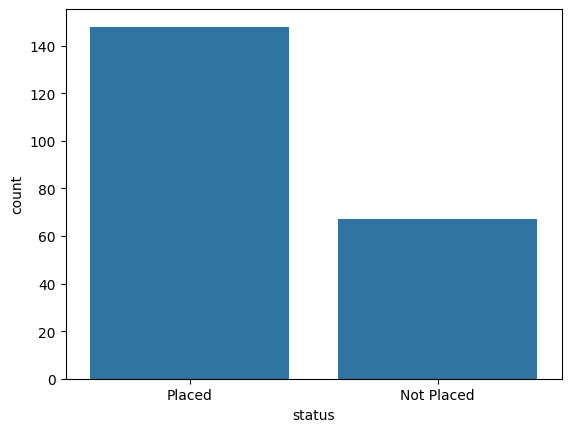

In [11]:
sns.countplot(x='status', data=df)
plt.show()

How degree percentage affects placements?

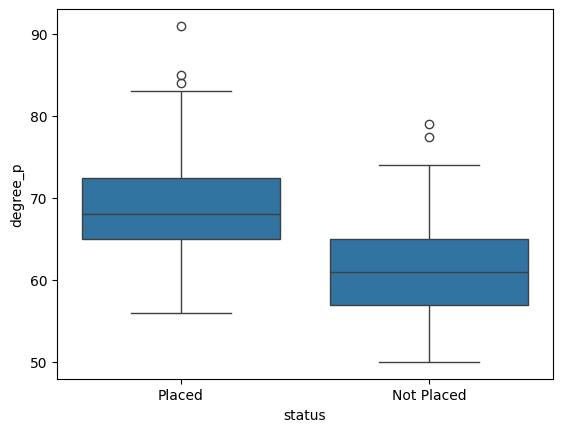

In [12]:
sns.boxplot(x='status', y='degree_p', data=df)
plt.show()

Work experience vs placement:

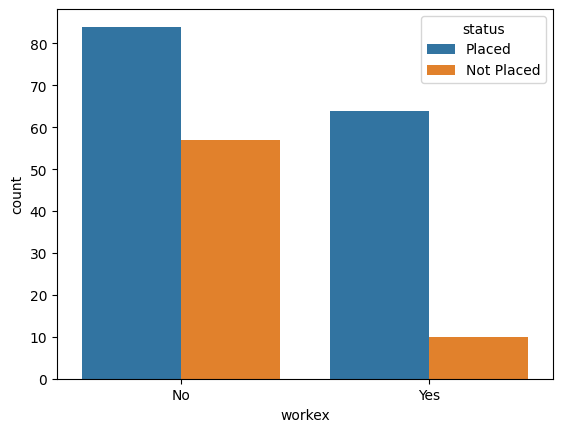

In [13]:
sns.countplot(x='workex', hue='status', data=df)
plt.show()

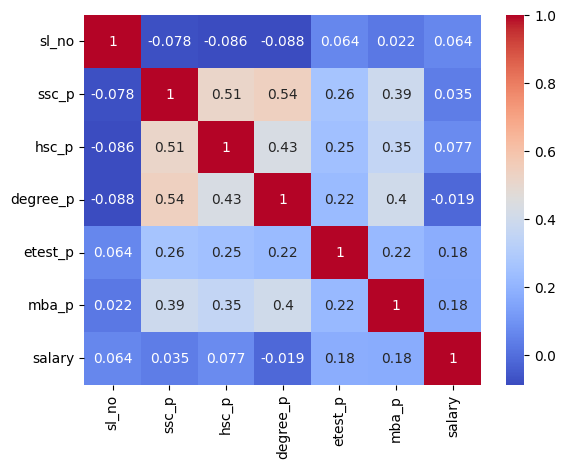

In [14]:
numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

# Cleaning the data before training.

There are too many missing values, therefore dropping **salary** and **sl_no**

In [15]:
df.drop('salary', axis=1, inplace=True)

In [16]:
df.drop('sl_no', axis=1, inplace=True)

In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split

X = df.drop('status', axis=1)
y = df['status']
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Trying Linear Regression model first:

In [25]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

Decision Tree:

In [27]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

Random forest model:

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

K Nearest Neighbors:

In [29]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

Comparing accuracies of all 4 models:

In [31]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

results = {
    "Logistic Regression":
        accuracy_score(y_test, lr_pred),

    "Decision Tree":
        accuracy_score(y_test, dt_pred),

    "Random Forest":
        accuracy_score(y_test, rf_pred),

    "KNN":
        accuracy_score(y_test, knn_pred)
}

print(results)

{'Logistic Regression': 0.8837209302325582, 'Decision Tree': 0.8372093023255814, 'Random Forest': 0.7906976744186046, 'KNN': 0.7906976744186046}


Bar chart showcasing the difference:

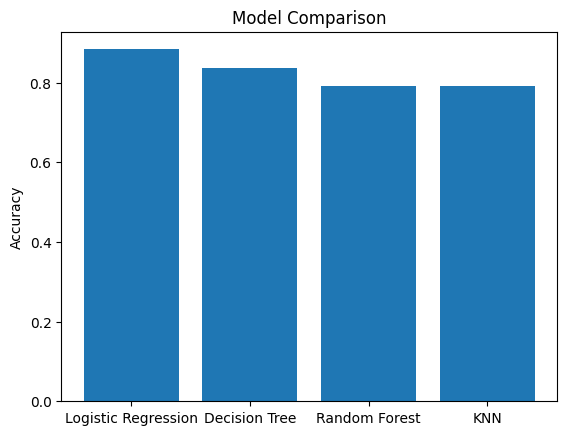

In [32]:
plt.bar(
    results.keys(),
    results.values()
)

plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

Surprisingly logistic regression has performed better here with an accuracy of 88 percent.

In [33]:
print(
    classification_report(
        y_test,
        lr_pred
    )
)

              precision    recall  f1-score   support

  Not Placed       0.82      0.75      0.78        12
      Placed       0.91      0.94      0.92        31

    accuracy                           0.88        43
   macro avg       0.86      0.84      0.85        43
weighted avg       0.88      0.88      0.88        43



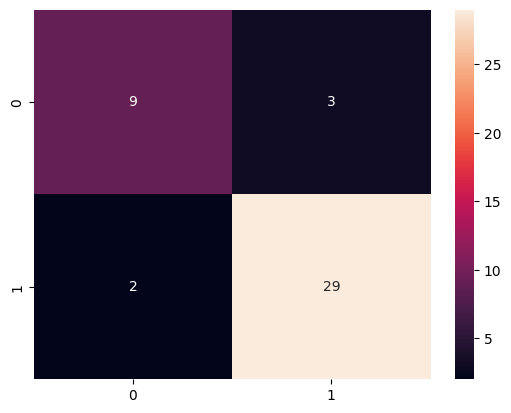

In [34]:
cm = confusion_matrix(
    y_test,
    lr_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.show()